In [2]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

# Make plots appear inside the notebook
%matplotlib inline

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATABASE = PROJECT_ROOT / "data" / "healthcare_claims.db"

conn = sqlite3.connect(DATABASE)

print(DATABASE)

/Users/simmi/Downloads/healthcare-claim-denial-analytics/data/healthcare_claims.db


In [4]:
claims = pd.read_sql(
    "SELECT * FROM claims",
    conn
)

claims.head()

,claim_id,patient_id,provider_id,submission_date,payer_name,plan_type,provider_specialty,cpt_code,icd10_code,claim_amount,...,provider_credentialed,coding_valid,duplicate_indicator,days_to_submit,claim_status,was_denied,denial_reason,amount_paid,revenue_leakage,denial_probability_true
0,CLM0000001,PAT000298,PRV0051,2025-01-13,Aetna Commercial,Commercial,Dermatology,70553,M17.11,729.58,...,1,1,0,12,Approved,0,Not Denied,678.74,50.84,0.0339
1,CLM0000002,PAT002579,PRV0033,2025-09-21,BlueShield Commercial,Commercial,Dermatology,99214,M17.11,1119.21,...,1,1,0,6,Approved,0,Not Denied,728.30,390.91,0.0373
2,CLM0000003,PAT002182,PRV0079,2025-03-20,Aetna Commercial,Commercial,Gastroenterology,93000,I10,2959.21,...,1,1,0,5,Approved,0,Not Denied,2104.22,854.99,0.0392
3,CLM0000004,PAT001463,PRV0100,2025-09-17,State Medicaid,Medicaid,Orthopedics,99214,I10,5848.79,...,1,1,0,7,Approved,0,Not Denied,4958.09,890.70,0.0794
4,CLM0000005,PAT001443,PRV0040,2025-07-26,Humana Medicare Advantage,Medicare Advantage,Orthopedics,71046,E11.9,5646.59,...,1,1,0,7,Denied,1,Medical Necessity / Other,0.00,5646.59,0.0660


In [5]:
claims.shape

(10000, 24)

In [6]:
claims.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   claim_id                 10000 non-null  str    
 1   patient_id               10000 non-null  str    
 2   provider_id              10000 non-null  str    
 3   submission_date          10000 non-null  str    
 4   payer_name               10000 non-null  str    
 5   plan_type                10000 non-null  str    
 6   provider_specialty       10000 non-null  str    
 7   cpt_code                 10000 non-null  int64  
 8   icd10_code               10000 non-null  str    
 9   claim_amount             10000 non-null  float64
 10  prior_auth_required      10000 non-null  int64  
 11  prior_auth_on_file       10000 non-null  int64  
 12  documentation_complete   10000 non-null  int64  
 13  eligibility_verified     10000 non-null  int64  
 14  provider_credentialed    10000 non

In [7]:
claims.isnull().sum().sort_values(ascending=False)

claim_id                   0
patient_id                 0
revenue_leakage            0
amount_paid                0
denial_reason              0
was_denied                 0
claim_status               0
days_to_submit             0
duplicate_indicator        0
coding_valid               0
provider_credentialed      0
eligibility_verified       0
documentation_complete     0
prior_auth_on_file         0
prior_auth_required        0
claim_amount               0
icd10_code                 0
cpt_code                   0
provider_specialty         0
plan_type                  0
payer_name                 0
submission_date            0
provider_id                0
denial_probability_true    0
dtype: int64

In [8]:
total_claims = len(claims)
denied_claims = claims["was_denied"].sum()
denial_rate = denied_claims / total_claims * 100

print(f"Total claims: {total_claims:,}")
print(f"Denied claims: {denied_claims:,}")
print(f"Denial rate: {denial_rate:.2f}%")

Total claims: 10,000
Denied claims: 1,254
Denial rate: 12.54%


In [9]:
payer_analysis = (
    claims.groupby("payer_name")
    .agg(
        total_claims=("claim_id", "count"),
        denied_claims=("was_denied", "sum")
    )
    .reset_index()
)

payer_analysis["denial_rate_pct"] = (
    payer_analysis["denied_claims"]
    / payer_analysis["total_claims"]
    * 100
)

payer_analysis = payer_analysis.sort_values(
    "denial_rate_pct",
    ascending=False
)

payer_analysis

,payer_name,total_claims,denied_claims,denial_rate_pct
1,Ambetter Marketplace,1488,259,17.405914
4,State Medicaid,2068,316,15.280464
3,Humana Medicare Advantage,1993,263,13.196187
0,Aetna Commercial,1952,183,9.375000
2,BlueShield Commercial,2499,233,9.323729


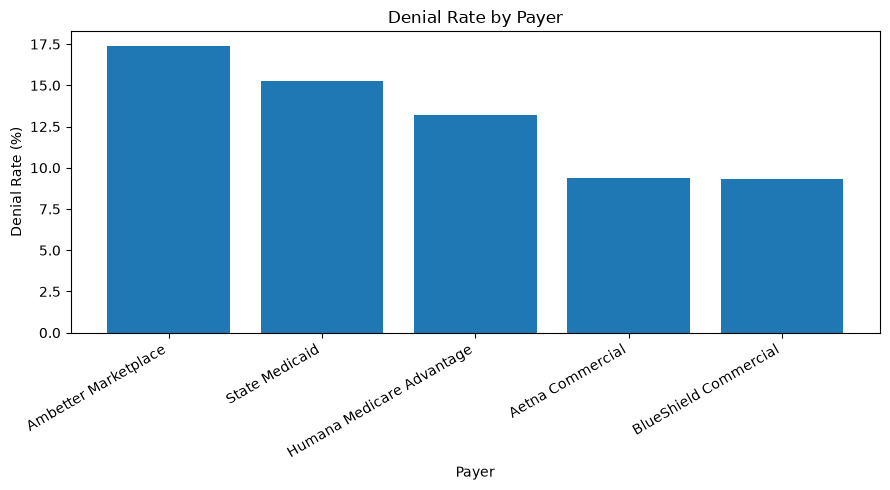

In [10]:
plt.figure(figsize=(9, 5))

plt.bar(
    payer_analysis["payer_name"],
    payer_analysis["denial_rate_pct"]
)

plt.title("Denial Rate by Payer")
plt.xlabel("Payer")
plt.ylabel("Denial Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [11]:
denial_reasons = (
    claims.loc[claims["was_denied"] == 1]
    .groupby("denial_reason")
    .agg(
        denied_claims=("claim_id", "count"),
        revenue_at_risk=("claim_amount", "sum")
    )
    .reset_index()
    .sort_values("revenue_at_risk", ascending=False)
)

denial_reasons

,denial_reason,denied_claims,revenue_at_risk
5,Prior Authorization Missing,386,951184.57
4,Medical Necessity / Other,344,777687.69
3,Eligibility Issue,166,369004.87
1,Documentation Incomplete,124,297488.51
0,Coding Error,103,266542.02
6,Provider Credentialing,68,150783.62
2,Duplicate Claim,61,127995.03
7,Timely Filing,2,1805.58


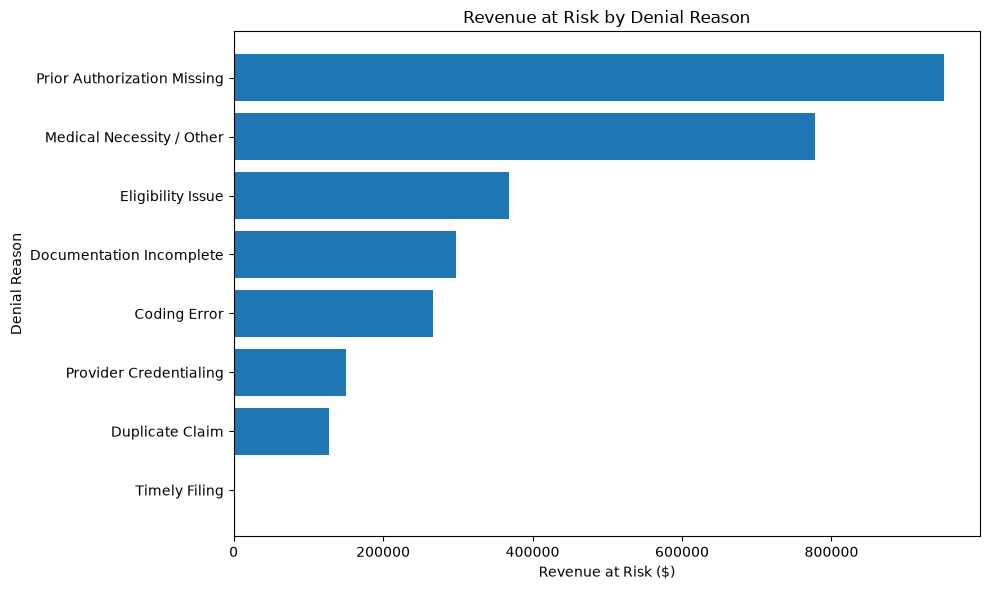

In [12]:
plt.figure(figsize=(10, 6))

plt.barh(
    denial_reasons["denial_reason"],
    denial_reasons["revenue_at_risk"]
)

plt.title("Revenue at Risk by Denial Reason")
plt.xlabel("Revenue at Risk ($)")
plt.ylabel("Denial Reason")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
specialty_analysis = (
    claims.groupby("provider_specialty")
    .agg(
        total_claims=("claim_id", "count"),
        denied_claims=("was_denied", "sum"),
        total_billed=("claim_amount", "sum")
    )
    .reset_index()
)

specialty_analysis["denial_rate_pct"] = (
    specialty_analysis["denied_claims"]
    / specialty_analysis["total_claims"]
    * 100
)

specialty_analysis.sort_values(
    "denial_rate_pct",
    ascending=False
)

,provider_specialty,total_claims,denied_claims,total_billed,denial_rate_pct
5,Radiology,1412,247,3629433.43,17.492918
3,Orthopedics,1526,250,5679555.14,16.382700
0,Cardiology,1449,177,3265243.01,12.215321
2,Gastroenterology,1412,161,3893793.57,11.402266
1,Dermatology,1387,142,2061029.28,10.237924
4,Primary Care,2814,277,3138034.41,9.843639


In [14]:
claims["submission_delay_group"] = pd.cut(
    claims["days_to_submit"],
    bins=[-1, 7, 14, 30, 60, float("inf")],
    labels=[
        "0–7 days",
        "8–14 days",
        "15–30 days",
        "31–60 days",
        "More than 60 days"
    ]
)

delay_analysis = (
    claims.groupby(
        "submission_delay_group",
        observed=False
    )
    .agg(
        total_claims=("claim_id", "count"),
        denied_claims=("was_denied", "sum")
    )
    .reset_index()
)

delay_analysis["denial_rate_pct"] = (
    delay_analysis["denied_claims"]
    / delay_analysis["total_claims"]
    * 100
)

delay_analysis

,submission_delay_group,total_claims,denied_claims,denial_rate_pct
0,0–7 days,3030,391,12.904290
1,8–14 days,3429,420,12.248469
2,15–30 days,3045,381,12.512315
3,31–60 days,491,59,12.016293
4,More than 60 days,5,3,60.000000
